# 📊 Unidad 3 — Clase 1: Ordenamiento Elemental

## Información del Curso

| Aspecto | Detalle |
|--------|--------|
| **Universidad** | Universidad de Talca, Chile |
| **Carrera** | Ingeniería Civil en Informática |
| **Semestre** | 2°-3° año |
| **Curso** | Algoritmos y Estructuras de Datos |
| **Docente** | PhD. César Astudillo |
| **Clase** | Unidad 3, Clase 1 — Selection Sort + Knuth Shuffle |
| **Duración estimada** | 90 minutos |
| **Prerequisitos** | Análisis de complejidad O(n), arreglos, intercambio de elementos |

## Mapa de la Clase

```
  1. El Problema del Ordenamiento (10 min)
       ↓
  2. Reglas del Juego: Costo y Modelo (10 min)
       ↓
  3. Selection Sort — Algoritmo e Invariante (25 min)
       ↓
  4. Knuth Shuffle — Barajado Uniforme (20 min)
       ↓
  5. Análisis de Complejidad Comparativo (10 min)
       ↓
  6. Widget Interactivo + Ejercicios (15 min)
```

## Verificación de Dependencias

In [1]:
import sys
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np
from timeit import timeit
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# Paleta de colores del curso
AZUL     = '#2196F3'   # elemento activo / comparado
NARANJA  = '#FF9800'   # candidato actual / mínimo candidato
VERDE    = '#4CAF50'   # prefijo ordenado / correcto
ROJO     = '#F44336'   # descartado / error
MORADO   = '#9C27B0'   # caso especial / swap
AZ_CLARO = '#90CAF9'   # visitado / sin ordenar
GRIS     = '#9E9E9E'   # neutro
FONDO    = '#FAFAFA'

try:
    from ordenamiento import (SelectionSort, KnuthShuffle,
                               is_sorted, contar_inversiones,
                               generar_lista_aleatoria, generar_lista_casi_ordenada)
    print("✓ Módulo 'ordenamiento' importado correctamente")
    print(f"  - SelectionSort: O(n²) comparaciones, O(n) swaps máx.")
    print(f"  - KnuthShuffle : O(n) barajado uniforme")
except ImportError as e:
    print(f"✗ Error al importar 'ordenamiento': {e}")
    print("  Asegúrate de que ordenamiento.py está en el mismo directorio")

print(f"\n✓ Matplotlib {plt.matplotlib.__version__} | NumPy {np.__version__}")
print("✓ Todas las dependencias verificadas. Listo para comenzar.")

✓ Módulo 'ordenamiento' importado correctamente
  - SelectionSort: O(n²) comparaciones, O(n) swaps máx.
  - KnuthShuffle : O(n) barajado uniforme

✓ Matplotlib 3.10.8 | NumPy 2.4.4
✓ Todas las dependencias verificadas. Listo para comenzar.


## Objetivos de Aprendizaje

Al finalizar esta clase, el estudiante será capaz de:

1. **Comprender** el problema del ordenamiento, su modelo de costo y las propiedades que definen un orden total
2. **Implementar** Selection Sort y explicar su invariante de ciclo paso a paso
3. **Analizar** por qué Selection Sort es siempre O(n²), aun con datos ya ordenados
4. **Implementar** el algoritmo de Knuth Shuffle y demostrar que genera permutaciones uniformes
5. **Distinguir** el error clásico del "naive shuffle" y explicar por qué no es uniforme

# Sección 1: El Problema del Ordenamiento (10 minutos)

## ¿Por qué ordenar?

Ordenar es la operación más fundamental en algoritmos. Sedgewick & Wayne (Algorithms, 4ª ed.) estiman que entre **el 25% y el 50%** del tiempo de cómputo histórico en mainframes se dedicó a ordenamiento.

Cuando los datos están ordenados, muchas operaciones se vuelven radicalmente más eficientes:

| Operación | Lista desordenada | Lista ordenada |
|-----------|-------------------|----------------|
| Buscar un elemento | O(n) búsqueda lineal | O(log n) búsqueda binaria |
| Detectar duplicados | O(n²) comparar todos | O(n) comparar adyacentes |
| Encontrar k-ésimo menor | O(n) con heap | O(1) directo |
| Unir dos colecciones | O(n·m) | O(n+m) merge |

## Orden Total: Las 3 propiedades

Para ordenar necesitamos comparar. La comparación `<` define un **orden total** si cumple:

> 📌 **Definición — Orden Total:**
> Una relación `<` es un orden total si para todo a, b, c:
> 1. **Antisimetría:** Si `a ≤ b` y `b ≤ a`, entonces `a = b`
> 2. **Transitividad:** Si `a ≤ b` y `b ≤ c`, entonces `a ≤ c`
> 3. **Totalidad:** Siempre se cumple `a ≤ b` o `b ≤ a` (o ambas)

> ⚠️ **Importante:** Nunca comparar `float` con `==` por errores de punto flotante. Para ordenar flotantes, usar `<` y `>` directamente.

## Modelo de Costo

Para comparar algoritmos de ordenamiento usamos dos métricas:

$$\text{costo} = \#\text{comparaciones} + \#\text{swaps}$$

- **Comparación:** `a[i] < a[j]` — acceso a dos elementos para decidir orden
- **Swap:** intercambio de dos elementos en el arreglo

> 💡 **Insight:** Las comparaciones dominan en tiempo. Los swaps dominan cuando mover datos es costoso (ej.: registros grandes en disco, memoria flash).

> 🎙️ **[PAUSA PROFESOR]** Pregunta: "¿En qué situaciones importa más minimizar swaps que comparaciones? ¿Y viceversa?" 

In [2]:
# Demo: Orden total en Python con enteros, strings y objetos personalizados

from functools import total_ordering

@total_ordering
class Carta:
    """Carta de un mazo estándar, comparable por valor (1-13)."""
    PALOS = ['♣', '♦', '♥', '♠']
    NOMBRES = {1:'A', 11:'J', 12:'Q', 13:'K'}

    def __init__(self, valor, palo):
        self.valor = valor
        self.palo = palo

    def __eq__(self, other):
        """ Dos cartas son iguales si tienen el mismo valor, sin importar el palo.
            Esto es solo para demostrar el orden total, no es la comparación real de cartas. """
        return self.valor == other.valor

    def __lt__(self, other):
        """ El orden se basa solo en el valor, ignorando el palo. """
        return self.valor < other.valor

    def __repr__(self):
        """ Representación en cadena de la carta. """
        nombre = self.NOMBRES.get(self.valor, str(self.valor))
        return f"{nombre}{self.palo}"

# Crear un mazo de cartas desordenado
mazo = [Carta(v, '♠') for v in [7, 2, 5, 1, 9, 4, 3]]

print("Mazo desordenado:", mazo)
print("¿Está ordenado?:", mazo[0] < mazo[1] < mazo[2])  # False

# Las comparaciones funcionan gracias al orden total
print(f"\n¿7♠ > 2♠? {mazo[0] > mazo[1]}")
print(f"¿1♠ < 9♠? {mazo[3] < mazo[4]}")
print(f"¿5♠ == 5♠? {mazo[2] == Carta(5, '♥')}")  # ← solo compara valor

print("\n✓ El decorador @total_ordering genera ≤, >, ≥ a partir de __eq__ y __lt__")

Mazo desordenado: [7♠, 2♠, 5♠, A♠, 9♠, 4♠, 3♠]
¿Está ordenado?: False

¿7♠ > 2♠? True
¿1♠ < 9♠? True
¿5♠ == 5♠? True

✓ El decorador @total_ordering genera ≤, >, ≥ a partir de __eq__ y __lt__


# Sección 2: Selection Sort (25 minutos)

## La Idea Central

Selection Sort divide el arreglo en dos partes:
- **Prefijo ordenado:** `a[0..i-1]` — ya está en su posición definitiva
- **Sufijo no ordenado:** `a[i..n-1]` — aún por colocar

En cada pasada `i`:
1. **Seleccionar** el mínimo de `a[i..n-1]` → índice `idx_min`
2. **Intercambiar** `a[i]` con `a[idx_min]`
3. El prefijo crece en uno: `a[0..i]` ya está ordenado

```
Ejemplo: [5, 3, 1, 4, 2]
         ─────────────────────────────────────────
Pasada 0: mín de [5,3,1,4,2] = 1 (pos 2) → swap(0,2) → [1 | 3,5,4,2]
Pasada 1: mín de [3,5,4,2]   = 2 (pos 4) → swap(1,4) → [1,2 | 5,4,3]
Pasada 2: mín de [5,4,3]     = 3 (pos 4) → swap(2,4) → [1,2,3 | 4,5]
Pasada 3: mín de [4,5]       = 4 (pos 3) → swap(3,3) → [1,2,3,4 | 5]
          ─────────────────────────────────────────
```

## Invariante del Ciclo

> 📌 **Invariante de Selection Sort:**
> Al inicio de la pasada `i`, los elementos `a[0], a[1], ..., a[i-1]`
> son los `i` elementos más pequeños del arreglo original, en orden.

## Código

```python
def selection_sort(a):
    n = len(a)
    for i in range(n - 1):                  # pasada i
        idx_min = i                          # asumir que a[i] es el mínimo
        for j in range(i + 1, n):           # buscar mínimo en a[i+1..n-1]
            if a[j] < a[idx_min]:
                idx_min = j
        a[i], a[idx_min] = a[idx_min], a[i] # swap: llevar mínimo a posición i
```

> 💡 **Insight clave:** Selection Sort hace **exactamente n*(n-1)/2 comparaciones**, siempre. No importa si el arreglo ya está ordenado — recorre todo el sufijo para encontrar el mínimo. Esto lo diferencia de Insertion Sort (que sí termina antes con datos casi ordenados).

> 🎙️ **[PAUSA PROFESOR]** "¿Qué pasaría si en lugar de buscar el mínimo, buscamos el máximo? ¿Cambiaría la complejidad?" 

In [3]:
# Demo: SelectionSort verbose — ver el algoritmo paso a paso

sorter = SelectionSort()
lista = [5, 3, 1, 4, 2]
sorter.ordenar_verbose(lista[:])  # usamos copia para no modificar el original

print(f"\nComprobación teórica:")
n = 5
comp_teoria = sorter.comparaciones_teoricas(n)
print(f"  n = {n} → comparaciones = n*(n-1)/2 = {n}*{n-1}/2 = {comp_teoria}")

Selection Sort — inicio: [5, 3, 1, 4, 2]
 Pasada |                  Array                   | idx_min | swap
─────────────────────────────────────────────────────────────────
      0 |             [1] [3, 5, 4, 2]             |       2 | 5 ↔ 1
      1 |             [1, 2] [5, 4, 3]             |       4 | 3 ↔ 2
      2 |             [1, 2, 3] [4, 5]             |       4 | 5 ↔ 3
      3 |             [1, 2, 3, 4] [5]             |       3 | —
─────────────────────────────────────────────────────────────────
Resultado: [1, 2, 3, 4, 5]
Total comparaciones: 10 | Total swaps: 3

Comprobación teórica:
  n = 5 → comparaciones = n*(n-1)/2 = 5*4/2 = 10


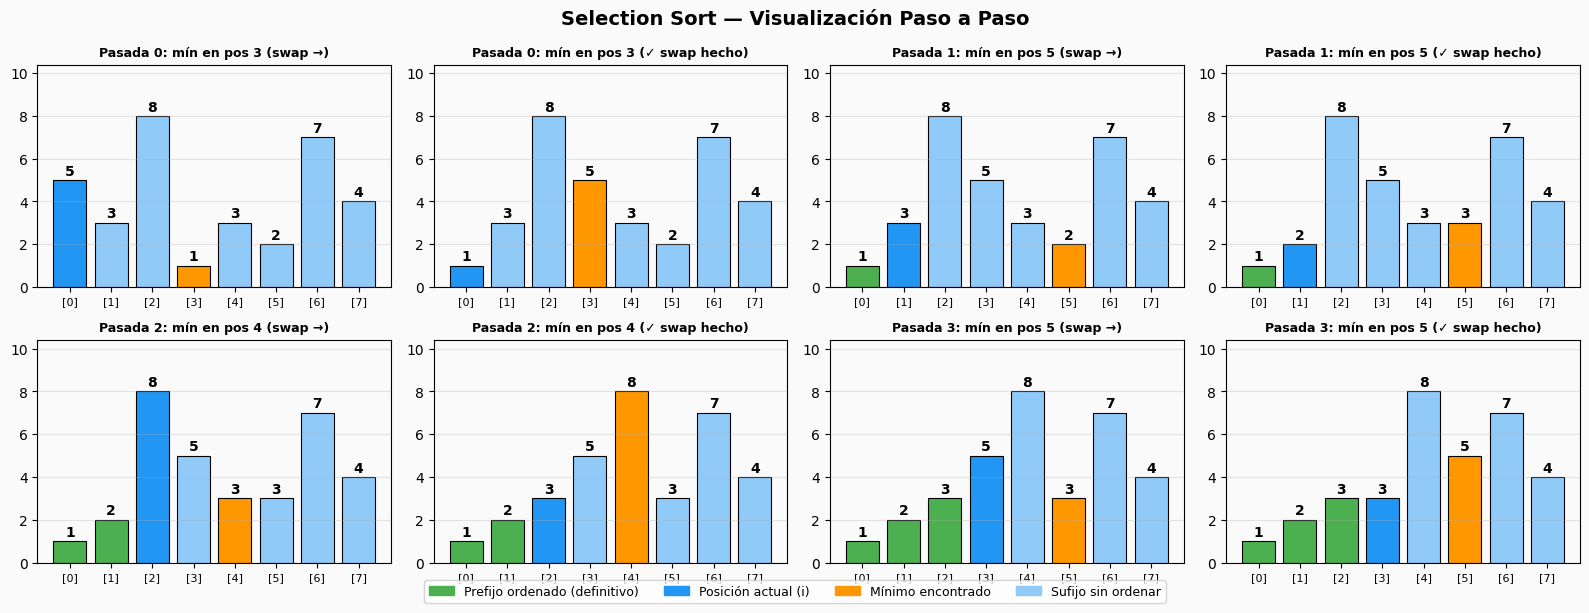

Visualización: cada barra muestra el estado del arreglo en cada pasada


In [6]:
# Visualización: Selection Sort paso a paso con matplotlib

def visualizar_selection_sort(lista_original):
    """Anima los pasos de Selection Sort con matplotlib."""
    lista = lista_original[:]
    n = len(lista)
    pasos = []  # guardamos (estado_array, i, idx_min, tipo)

    # Simular y capturar estados
    for i in range(n - 1):
        idx_min = i
        for j in range(i + 1, n):
            if lista[j] < lista[idx_min]:
                idx_min = j
        pasos.append((lista[:], i, idx_min, 'antes_swap'))
        if idx_min != i:
            lista[i], lista[idx_min] = lista[idx_min], lista[i]
        pasos.append((lista[:], i, idx_min, 'despues_swap'))

    # Calcular cuántas filas necesitamos
    n_pasos_mostrar = min(len(pasos), 8)  # mostrar hasta 8 pasos
    indices = list(range(0, len(pasos), max(1, len(pasos) // n_pasos_mostrar)))[:8]

    fig, axes = plt.subplots(2, 4, figsize=(16, 6))
    fig.suptitle('Selection Sort — Visualización Paso a Paso', fontsize=14, fontweight='bold')
    fig.patch.set_facecolor(FONDO)

    for plot_idx, paso_idx in enumerate(indices[:8]):
        ax = axes[plot_idx // 4][plot_idx % 4]
        arr, i, idx_min, tipo = pasos[paso_idx]

        colores = []
        for k in range(n):
            if k < i:
                colores.append(VERDE)      # prefijo ordenado
            elif k == i:
                colores.append(AZUL)       # posición a llenar
            elif k == idx_min:
                colores.append(NARANJA)    # mínimo encontrado
            else:
                colores.append(AZ_CLARO)  # sufijo sin ordenar

        bars = ax.bar(range(n), arr, color=colores, edgecolor='black', linewidth=0.8)
        for k, bar in enumerate(bars):
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
                   str(arr[k]), ha='center', va='bottom', fontsize=10, fontweight='bold')

        accion = "swap →" if tipo == 'antes_swap' else "✓ swap hecho"
        ax.set_title(f'Pasada {i}: mín en pos {idx_min} ({accion})', fontsize=9, fontweight='bold')
        ax.set_ylim(0, max(lista_original) * 1.3)
        ax.set_xticks(range(n))
        ax.set_xticklabels([f'[{k}]' for k in range(n)], fontsize=8)
        ax.set_facecolor(FONDO)
        ax.grid(axis='y', alpha=0.3)

    # Leyenda
    leyenda = [
        mpatches.Patch(color=VERDE,    label='Prefijo ordenado (definitivo)'),
        mpatches.Patch(color=AZUL,     label='Posición actual (i)'),
        mpatches.Patch(color=NARANJA,  label='Mínimo encontrado'),
        mpatches.Patch(color=AZ_CLARO, label='Sufijo sin ordenar'),
    ]
    fig.legend(handles=leyenda, loc='lower center', ncol=4, fontsize=9,
               bbox_to_anchor=(0.5, -0.02))

    plt.tight_layout()
    plt.savefig('/tmp/selection_sort_pasos.png', dpi=100, bbox_inches='tight')
    plt.show()
    print("Visualización: cada barra muestra el estado del arreglo en cada pasada")

visualizar_selection_sort([5, 3, 8, 1, 3, 2, 7, 4])

In [ ]:
# Verificación: la invariante se cumple en cada pasada

def verificar_invariante_selection_sort(lista):
    """
    Verifica explícitamente la invariante de Selection Sort.
    Invariante: al terminar la pasada i, a[0..i] son los i+1 mínimos en orden.
    """
    a = lista[:]
    n = len(a)
    original_sorted = sorted(lista)

    print(f"Lista original: {lista}")
    print(f"Lista ordenada: {original_sorted}")
    print(f"\nVerificando invariante en cada pasada:")
    print(f"{'Pasada':>7} | {'Prefijo ordenado':^30} | {'¿Invariante?':>12}")
    print("─" * 60)

    for i in range(n - 1):
        idx_min = i
        for j in range(i + 1, n):
            if a[j] < a[idx_min]:
                idx_min = j
        if idx_min != i:
            a[i], a[idx_min] = a[idx_min], a[i]

        prefijo = a[:i+1]
        esperado = original_sorted[:i+1]
        ok = prefijo == esperado
        estado = "✓ CUMPLE" if ok else "✗ FALLA"
        print(f"{i:>7} | {str(prefijo):^30} | {estado:>12}")

    print("─" * 60)
    print(f"Resultado final: {a}")
    print(f"✓ Invariante verificada en todas las pasadas: {a == original_sorted}")

verificar_invariante_selection_sort([7, 2, 5, 1, 9, 4, 3, 8, 6])

# Sección 3: Knuth Shuffle — Barajado Uniforme (20 minutos)

## ¿Por qué necesitamos barajar?

El barajado uniforme tiene aplicaciones críticas:
- **Monte Carlo:** simulaciones que requieren muestras aleatorias verdaderas
- **Criptografía:** generación de claves y vectores de inicialización
- **Testing de algoritmos:** generar casos de prueba no sesgados
- **Juegos:** naipes, sorteos, listas de reproducción aleatorias
- **A/B testing:** asignación aleatoria de usuarios a grupos

> 📌 **Definición — Permutación Uniforme:**
> Una permutación es **uniforme** si cada una de las `n\!` permutaciones posibles
> tiene exactamente la misma probabilidad de ocurrir: `P = 1/n\!`

## Error Clásico: El Naive Shuffle

```python
# ❌ INCORRECTO — NO genera permutaciones uniformes
def naive_shuffle(a):
    n = len(a)
    for i in range(n):
        j = random.randint(0, n-1)   # ← j en [0, n-1], ¡ERROR\!
        a[i], a[j] = a[j], a[i]
```

¿Por qué falla? Para n=3 elementos:
- Hay `3\! = 6` permutaciones distintas
- Pero el algoritmo puede producir `3^3 = 27` secuencias de decisiones
- Como `27` no es divisible por `6`, **alguna permutación ocurre más que otras**

## El Algoritmo Correcto: Knuth Shuffle

```python
# ✓ CORRECTO — Knuth/Fisher-Yates O(n) uniforme
def knuth_shuffle(a):
    n = len(a)
    for i in range(n - 1):
        j = random.randint(i, n-1)    # ← j en [i, n-1], ¡CRUCIAL\!
        a[i], a[j] = a[j], a[i]
```

**¿Por qué funciona?**

Análisis por inducción en la posición `i`:
- En paso `i`, hay `(n-i)` posibles valores para `j` → cada uno con prob `1/(n-i)`
- El elemento que termina en posición `i` fue "elegido" de entre `(n-i)` candidatos
- Por inducción: la probabilidad total de cada permutación es
  $$P = \frac{1}{n} \cdot \frac{1}{n-1} \cdot \frac{1}{n-2} \cdots \frac{1}{2} = \frac{1}{n\!}$$

> 💡 **Insight:** Knuth Shuffle es Selection Sort al revés: en lugar de encontrar el **mínimo**, elige un elemento **aleatorio**. Ambos tienen la misma estructura de doble bucle / bucle con swap.

> ⚠️ **Importante:** El generador `random.randint(i, n-1)` debe usar `i` como límite inferior, NO `0`. Este es el error más común al implementar el shuffle.

> 🎙️ **[PAUSA PROFESOR]** "¿Cuántas permutaciones distintas puede generar el naive shuffle para n=3? ¿Por qué eso es un problema?" 

In [7]:
# Demo: KnuthShuffle verbose — ver el algoritmo paso a paso

shuffler = KnuthShuffle(semilla=42)  # semilla para reproducibilidad
lista = [1, 2, 3, 4, 5]
shuffler.barajar_verbose(lista[:])

print(f"\nResultados con diferentes semillas:")
for semilla in [1, 7, 13, 42, 99]:
    k = KnuthShuffle(semilla=semilla)
    resultado = k.barajar([1, 2, 3, 4, 5])
    print(f"  semilla={semilla:3d} → {resultado}")

Knuth Shuffle — inicio: [1, 2, 3, 4, 5]
 Paso |   i | j (aleatorio) |      swap       | Array
─────────────────────────────────────────────────────────────────
    0 |   0 |             0 |    — (mismo)    | [1, 2, 3, 4, 5]
    1 |   1 |             1 |    — (mismo)    | [1, 2, 3, 4, 5]
    2 |   2 |             4 |      3 ↔ 5      | [1, 2, 5, 4, 3]
    3 |   3 |             4 |      4 ↔ 3      | [1, 2, 5, 3, 4]
─────────────────────────────────────────────────────────────────
Resultado: [1, 2, 5, 3, 4]
Total swaps realizados: 2

Resultados con diferentes semillas:
  semilla=  1 → [2, 1, 4, 3, 5]
  semilla=  7 → [3, 1, 4, 2, 5]
  semilla= 13 → [3, 4, 5, 2, 1]
  semilla= 42 → [1, 2, 5, 3, 4]
  semilla= 99 → [4, 5, 3, 1, 2]


/var/folders/hq/j1mtxtzj67j363wbx6731f6r0000gn/T/ipykernel_61061/1926390895.py:64: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/hq/j1mtxtzj67j363wbx6731f6r0000gn/T/ipykernel_61061/1926390895.py:65: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('/tmp/shuffle_distribucion.png', dpi=100, bbox_inches='tight')
/Users/cesar/GIT/ALG_PYTHON_Private/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


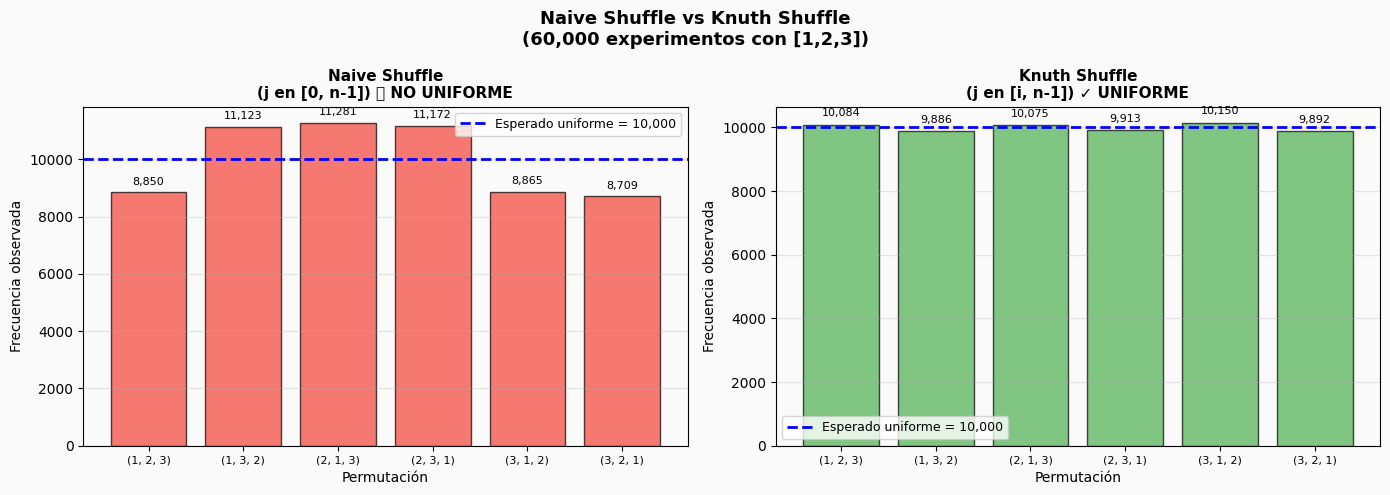


Análisis: Desviación del valor esperado (60,000/6 = 10,000):
Permutación          Naive      Knuth   Diff Naive   Diff Knuth
────────────────────────────────────────────────────────────
(1, 2, 3)            8,850     10,084       11.5%        0.8%
(1, 3, 2)           11,123      9,886       11.2%        1.1%
(2, 1, 3)           11,281     10,075       12.8%        0.8%
(2, 3, 1)           11,172      9,913       11.7%        0.9%
(3, 1, 2)            8,865     10,150       11.3%        1.5%
(3, 2, 1)            8,709      9,892       12.9%        1.1%


In [8]:
# Demostración: Naive Shuffle vs Knuth Shuffle — distribución de permutaciones

from collections import Counter

def naive_shuffle_demo(lista):
    """Naive Shuffle — genera distribución NO uniforme."""
    a = lista[:]
    n = len(a)
    for i in range(n):
        j = random.randint(0, n - 1)  # ← j en [0, n-1]: ERROR
        a[i], a[j] = a[j], a[i]
    return tuple(a)

def knuth_shuffle_demo(lista):
    """Knuth Shuffle — genera distribución uniforme."""
    a = lista[:]
    n = len(a)
    for i in range(n - 1):
        j = random.randint(i, n - 1)  # ← j en [i, n-1]: CORRECTO
        a[i], a[j] = a[j], a[i]
    return tuple(a)

# Experimento: 60,000 shuffles de [1, 2, 3]
random.seed(0)
N_EXPERIMENTOS = 60_000
lista_base = [1, 2, 3]

contador_naive  = Counter(naive_shuffle_demo(lista_base)  for _ in range(N_EXPERIMENTOS))
contador_knuth  = Counter(knuth_shuffle_demo(lista_base)  for _ in range(N_EXPERIMENTOS))

# Visualizar distribución
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Naive Shuffle vs Knuth Shuffle\n(60,000 experimentos con [1,2,3])',
             fontsize=13, fontweight='bold')
fig.patch.set_facecolor(FONDO)

esperado_uniforme = N_EXPERIMENTOS / 6  # 6 permutaciones para n=3

for ax, contador, titulo, color in [
    (ax1, contador_naive, 'Naive Shuffle\n(j en [0, n-1]) ❌ NO UNIFORME', ROJO),
    (ax2, contador_knuth, 'Knuth Shuffle\n(j en [i, n-1]) ✓ UNIFORME', VERDE)
]:
    perms = sorted(contador.keys())
    conteos = [contador[p] for p in perms]
    etiquetas = [str(p) for p in perms]

    bars = ax.bar(range(len(perms)), conteos, color=color, alpha=0.7, edgecolor='black')
    ax.axhline(y=esperado_uniforme, color='blue', linestyle='--', linewidth=2,
               label=f'Esperado uniforme = {esperado_uniforme:,.0f}')

    for bar, conteo in zip(bars, conteos):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 200,
               f'{conteo:,}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(range(len(perms)))
    ax.set_xticklabels(etiquetas, fontsize=8)
    ax.set_ylabel('Frecuencia observada')
    ax.set_xlabel('Permutación')
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_facecolor(FONDO)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/tmp/shuffle_distribucion.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nAnálisis: Desviación del valor esperado (60,000/6 = 10,000):")
print(f"{'Permutación':<15} {'Naive':>10} {'Knuth':>10} {'Diff Naive':>12} {'Diff Knuth':>12}")
print("─" * 60)
for p in sorted(set(contador_naive.keys()) | set(contador_knuth.keys())):
    cn = contador_naive.get(p, 0)
    ck = contador_knuth.get(p, 0)
    dn = abs(cn - esperado_uniforme) / esperado_uniforme * 100
    dk = abs(ck - esperado_uniforme) / esperado_uniforme * 100
    print(f"{str(p):<15} {cn:>10,} {ck:>10,} {dn:>10.1f}% {dk:>10.1f}%")

# Sección 4: La Conexión Profunda (5 minutos)

## Selection Sort y Knuth Shuffle: Dos caras de la misma moneda

Ambos algoritmos comparten la misma estructura básica:

```
for i in range(n - 1):
    # Elegir un índice especial en [i, n-1]
    idx_especial = ...
    # Intercambiar a[i] con a[idx_especial]
    a[i], a[idx_especial] = a[idx_especial], a[i]
```

La diferencia es **cómo se elige `idx_especial`**:

| Algoritmo | Criterio de selección | Objetivo | Complejidad |
|-----------|----------------------|----------|-------------|
| **Selection Sort** | `idx_min`: posición del **mínimo** en `a[i..n-1]` | Ordenar | O(n²) |
| **Knuth Shuffle** | `j`: posición **aleatoria** en `a[i..n-1]` | Barajar | O(n) |

Selection Sort es O(n²) porque encontrar el mínimo requiere un bucle interno O(n).
Knuth Shuffle es O(n) porque elegir un índice aleatorio es O(1).

> 💡 **Reflexión final:** Ordenar (crear orden) y barajar (crear desorden) son operaciones complementarias. La primera es inevitablemente O(n log n) como límite óptimo. La segunda puede hacerse en O(n). ¿Por qué esa asimetría? Porque "destruir" información (desorden) es más fácil que "crearla" (orden).

# Sección 5: Análisis de Complejidad (10 minutos)

## Selection Sort: Análisis Exacto

$$T(n) = \sum_{i=0}^{n-2} (n - 1 - i) = (n-1) + (n-2) + \cdots + 1 = \frac{n(n-1)}{2} = \Theta(n^2)$$

**Comparaciones:** Siempre exactamente $\frac{n(n-1)}{2}$

**Swaps:** Entre 0 (ya ordenado) y n-1 (cada elemento fuera de lugar)

> 📌 **Característica única:** Selection Sort hace el **mínimo número de swaps posible** entre los algoritmos de ordenamiento basados en comparaciones. Esto lo hace valioso cuando mover datos es costoso.

## Knuth Shuffle: Análisis

$$T(n) = n - 1 \text{ iteraciones} \times O(1) \text{ por iteración} = O(n)$$

**Swaps:** Entre 0 y n-1 (en promedio ≈ n·(1 - 1/e) ≈ 0.632n)

In [ ]:
# Benchmark: Selection Sort vs datos ya ordenados vs datos inversos

import timeit

print("BENCHMARK: Selection Sort — ¿importa el orden inicial?")
print("="*65)

sizes = [50, 100, 200, 500]
resultados = {
    'aleatorio': [],
    'ya_ordenado': [],
    'inverso': []
}

for n in sizes:
    for tipo, generador in [
        ('aleatorio',    lambda n=n: list(range(n))),
        ('ya_ordenado',  lambda n=n: list(range(n))),
        ('inverso',      lambda n=n: list(range(n, 0, -1)))
    ]:
        # Para 'aleatorio' mezclamos
        if tipo == 'aleatorio':
            lista_gen = lambda n=n: sorted(generar_lista_aleatoria(n))
        else:
            lista_gen = generador

        t = timeit.timeit(
            lambda: SelectionSort().ordenar(lista_gen()[:]),
            number=200
        )
        resultados[tipo].append(t)

    print(f"n={n:4d} | aleat={resultados['aleatorio'][-1]:.4f}s | "
          f"ordenado={resultados['ya_ordenado'][-1]:.4f}s | "
          f"inverso={resultados['inverso'][-1]:.4f}s")

print("\nCONCLUSIÓN: Los tres tiempos son prácticamente iguales.")
print("Selection Sort siempre hace n*(n-1)/2 comparaciones, sin importar el input.")
print("Esto contrasta con Insertion Sort (que SÍ es más rápido con datos casi ordenados).")

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(FONDO)
ax.set_facecolor(FONDO)

colores = [AZUL, VERDE, ROJO]
for (tipo, datos), color in zip(resultados.items(), colores):
    ax.plot(sizes, datos, marker='o', linewidth=2.5, label=tipo, color=color, markersize=8)

ax.set_xlabel('Tamaño n', fontsize=12, fontweight='bold')
ax.set_ylabel('Tiempo (s)', fontsize=12, fontweight='bold')
ax.set_title('Selection Sort: Tiempo vs Tipo de Input\n(insensible al orden inicial)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/tmp/selection_benchmark.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
# Tabla comparativa de complejidad

import pandas as pd

datos = {
    'Algoritmo': ['Selection Sort', 'Knuth Shuffle', 'Bubble Sort (ref.)', 'Insertion Sort (ref.)'],
    'Comparaciones': ['Θ(n²) siempre', 'O(1) (no compara)', 'O(n²) peor/prom', 'O(n²) peor, O(n) mejor'],
    'Swaps': ['≤ n-1 (mínimo\!)', 'n-1 exactos', 'O(n²)', 'O(n²) peor, O(1) mejor'],
    'Espacio': ['O(1)', 'O(1)', 'O(1)', 'O(1)'],
    'Estable': ['No', 'N/A', 'Sí', 'Sí'],
    'Mejor caso': ['Θ(n²)', 'Θ(n)', 'Θ(n) con optimiz.', 'Θ(n)'],
    'Uso típico': ['Memoria flash limitada', 'Testing, juegos, Monte Carlo', 'Didáctico', 'Datos casi ordenados'],
}

df = pd.DataFrame(datos)
print("\nTABLA COMPARATIVA DE ALGORITMOS ELEMENTALES:")
print("="*100)
print(df.to_string(index=False))
print("="*100)
print("\n* Selection Sort: único algoritmo elemental que minimiza swaps. Útil para memoria flash.")
print("* Knuth Shuffle: no es un algoritmo de ordenamiento, sino su complemento.")

# Sección 6: Widget Interactivo — Simulador Visual

In [ ]:
# Widget interactivo: Selection Sort animado

class SimuladorOrdenamiento:
    def __init__(self):
        # Controles
        self.slider_n = widgets.IntSlider(
            value=8, min=4, max=15, step=1,
            description='n:', style={'description_width': 'initial'}
        )
        self.btn_nuevo = widgets.Button(description='🎲 Nueva lista', button_style='primary')
        self.btn_paso  = widgets.Button(description='▶ Siguiente paso', button_style='info')
        self.btn_todo  = widgets.Button(description='⏩ Ordenar todo', button_style='warning')
        self.btn_shuffle = widgets.Button(description='🔀 Shuffle', button_style='danger')
        self.output    = widgets.Output()

        # Estado interno
        self.lista = []
        self.paso_actual = 0
        self.pasos_selec = []  # (array, i, idx_min, tipo)
        self._generar_nueva_lista()

        # Eventos
        self.btn_nuevo.on_click(lambda b: self._nueva())
        self.btn_paso.on_click(lambda b: self._avanzar_paso())
        self.btn_todo.on_click(lambda b: self._ordenar_todo())
        self.btn_shuffle.on_click(lambda b: self._shuffle())

    def _generar_nueva_lista(self):
        n = self.slider_n.value
        self.lista = generar_lista_aleatoria(n, (1, 20))
        self.paso_actual = 0
        self._precomputar_pasos()

    def _precomputar_pasos(self):
        a = self.lista[:]
        n = len(a)
        self.pasos_selec = [(a[:], -1, -1, 'inicio')]
        for i in range(n - 1):
            idx_min = i
            for j in range(i + 1, n):
                if a[j] < a[idx_min]:
                    idx_min = j
            self.pasos_selec.append((a[:], i, idx_min, 'antes_swap'))
            if idx_min != i:
                a[i], a[idx_min] = a[idx_min], a[i]
            self.pasos_selec.append((a[:], i, idx_min, 'despues_swap'))
        self.pasos_selec.append((a[:], n, -1, 'final'))

    def _nueva(self):
        self._generar_nueva_lista()
        self._dibujar(0)

    def _shuffle(self):
        k = KnuthShuffle()
        k.barajar(self.lista)
        self.paso_actual = 0
        self._precomputar_pasos()
        self._dibujar(0)

    def _avanzar_paso(self):
        if self.paso_actual < len(self.pasos_selec) - 1:
            self.paso_actual += 1
        self._dibujar(self.paso_actual)

    def _ordenar_todo(self):
        self.paso_actual = len(self.pasos_selec) - 1
        self._dibujar(self.paso_actual)

    def _dibujar(self, idx_paso):
        arr, i, idx_min, tipo = self.pasos_selec[idx_paso]
        n = len(arr)

        with self.output:
            clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(max(8, n*0.8), 4))
            fig.patch.set_facecolor(FONDO)
            ax.set_facecolor(FONDO)

            colores = []
            for k in range(n):
                if tipo == 'final' or k < i:
                    colores.append(VERDE)
                elif k == i:
                    colores.append(AZUL)
                elif k == idx_min:
                    colores.append(NARANJA)
                else:
                    colores.append(AZ_CLARO)

            bars = ax.bar(range(n), arr, color=colores, edgecolor='black', linewidth=1)
            for k, bar in enumerate(bars):
                ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
                       str(arr[k]), ha='center', va='bottom', fontsize=11, fontweight='bold')

            if tipo == 'inicio':
                titulo = "Estado inicial (sin ordenar)"
            elif tipo == 'antes_swap':
                titulo = f"Pasada {i}: mínimo en pos {idx_min} (valor={arr[idx_min]}) → swap pendiente"
            elif tipo == 'despues_swap':
                titulo = f"Pasada {i}: swap realizado — prefijo ordenado: {arr[:i+1]}"
            else:
                titulo = f"✓ Ordenamiento completo en {len(self.pasos_selec)-1} pasos"

            ax.set_title(titulo, fontsize=11, fontweight='bold')
            ax.set_ylim(0, max(arr) * 1.35)
            ax.set_xticks(range(n))
            ax.set_xticklabels([f'[{k}]' for k in range(n)])
            ax.grid(axis='y', alpha=0.3)

            paso_str = f"Paso {idx_paso}/{len(self.pasos_selec)-1}"
            ax.text(0.98, 0.95, paso_str, transform=ax.transAxes,
                   ha='right', va='top', fontsize=9, color=GRIS)

            plt.tight_layout()
            plt.show()

    def mostrar(self):
        self._dibujar(0)
        controles = widgets.HBox([
            self.slider_n, self.btn_nuevo, self.btn_paso,
            self.btn_todo, self.btn_shuffle
        ])
        display(widgets.VBox([
            widgets.HTML("<h3>🎮 Simulador: Selection Sort + Knuth Shuffle</h3>"),
            controles,
            self.output
        ]))

sim = SimuladorOrdenamiento()
sim.mostrar()
print("\n✓ Widget listo. Usa los botones para controlar la simulación.")

# Sección 7: Ejercicios Prácticos

## 🧪 Ejercicio 1 ⭐: Selection Sort con Trazado Manual

**Descripción:** Implementa la función `selection_sort_contar` que ordena la lista
**y** retorna el número exacto de comparaciones y swaps realizados.

**Entrada:** Lista de enteros
**Salida:** Tupla `(lista_ordenada, n_comparaciones, n_swaps)`

**Ejemplo:**
```
Entrada: [3, 1, 4, 1, 5]
Salida:  ([1, 1, 3, 4, 5], 10, 3)
```

**Restricciones:** n ≤ 1000  
**Complejidad esperada:** O(n²) comparaciones, O(n) swaps

In [ ]:
def selection_sort_contar(lista):
    """
    Ordena lista y cuenta comparaciones y swaps.

    Parámetros:
        lista (list): Lista de elementos comparables.

    Retorna:
        tuple: (lista_ordenada, n_comparaciones, n_swaps)

    Complejidad:
        Temporal: O(n²)
        Espacial: O(1)
    """
    # Tu código aquí
    raise NotImplementedError("Implementa selection_sort_contar")

In [ ]:
def verificar_ejercicio_1(fn):
    """Verificador automático para el ejercicio 1."""
    import time
    casos = [
        (([3, 1, 4, 1, 5],),  ([1, 1, 3, 4, 5], 10, 3),  "Caso normal con repetidos"),
        (([1, 2, 3, 4, 5],),  ([1, 2, 3, 4, 5], 10, 0),  "Ya ordenado (0 swaps)"),
        (([5, 4, 3, 2, 1],),  ([1, 2, 3, 4, 5], 10, 2),  "Orden inverso"),
        (([42],),             ([42], 0, 0),               "Un solo elemento"),
        (([2, 1],),           ([1, 2], 1, 1),             "Dos elementos"),
        (([7, 7, 7],),        ([7, 7, 7], 3, 0),          "Todos iguales"),
    ]
    aprobados = 0
    for args, esperado, descripcion in casos:
        t0 = time.perf_counter()
        try:
            resultado = fn(*args)
            t1 = time.perf_counter()
            lista_res, comp_res, swap_res = resultado
            lista_esp, comp_esp, swap_esp = esperado
            ok_lista = lista_res == lista_esp
            ok_comp  = comp_res == comp_esp
            ok_swap  = swap_res == swap_esp
            if ok_lista and ok_comp and ok_swap:
                print(f"  ✅ {descripcion} ({(t1-t0)*1000:.2f}ms)")
                aprobados += 1
            else:
                print(f"  ❌ {descripcion}")
                if not ok_lista: print(f"     Lista → esperado: {lista_esp}, obtenido: {lista_res}")
                if not ok_comp:  print(f"     Comp  → esperado: {comp_esp}, obtenido: {comp_res}")
                if not ok_swap:  print(f"     Swaps → esperado: {swap_esp}, obtenido: {swap_res}")
        except Exception as e:
            print(f"  💥 {descripcion} — Error: {e}")
    print(f"\n{'🎉 Todos los casos pasaron\!' if aprobados == len(casos) else f'⚠️  {aprobados}/{len(casos)} casos correctos'}")

verificar_ejercicio_1(selection_sort_contar)

In [ ]:
# ═══════════════════════════════════════════════════
# SOLUCIÓN — Descomenta para ver después de intentarlo
# ═══════════════════════════════════════════════════

# def selection_sort_contar(lista):
#     a = lista[:]
#     n = len(a)
#     comparaciones = 0
#     swaps = 0
#     for i in range(n - 1):
#         idx_min = i
#         for j in range(i + 1, n):
#             comparaciones += 1
#             if a[j] < a[idx_min]:
#                 idx_min = j
#         if idx_min != i:
#             a[i], a[idx_min] = a[idx_min], a[i]
#             swaps += 1
#     return (a, comparaciones, swaps)

## 🧪 Ejercicio 2 ⭐⭐: Verificar Uniformidad del Knuth Shuffle

**Descripción:** Implementa `prueba_uniformidad_shuffle(shuffle_fn, lista, n_exp)`
que corre `n_exp` experimentos y verifica si la distribución de permutaciones
es aproximadamente uniforme (variación coeficiente < 5%).

**Entrada:** Función de shuffle, lista base, número de experimentos
**Salida:** Tupla `(es_uniforme, variacion_coef)` donde `es_uniforme = vc < 0.05`

**Complejidad esperada:** O(n × n_exp)

In [ ]:
from collections import Counter
import math

def prueba_uniformidad_shuffle(shuffle_fn, lista, n_exp=10_000):
    """
    Prueba si shuffle_fn genera permutaciones uniformes.

    Parámetros:
        shuffle_fn: Función que toma una lista y la baraja in-place.
        lista: Lista base a barajar.
        n_exp (int): Número de experimentos.

    Retorna:
        tuple: (es_uniforme: bool, variacion_coef: float)
               es_uniforme = True si coef. de variación < 0.05 (5%)
    """
    # Tu código aquí
    raise NotImplementedError("Implementa prueba_uniformidad_shuffle")

In [ ]:
def verificar_ejercicio_2(fn):
    """Verificador para el ejercicio 2."""
    import time

    # Test 1: Knuth debe ser uniforme
    t0 = time.perf_counter()
    try:
        def knuth_fn(a):
            KnuthShuffle().barajar(a)
        es_unif, vc = fn(knuth_fn, [1, 2, 3], 30_000)
        t1 = time.perf_counter()
        if es_unif and vc < 0.05:
            print(f"  ✅ Knuth Shuffle es uniforme (vc={vc:.4f}) ({(t1-t0)*1000:.0f}ms)")
        else:
            print(f"  ❌ Knuth debería ser uniforme (vc={vc:.4f})")
    except Exception as e:
        print(f"  💥 Knuth Shuffle — Error: {e}")

    # Test 2: Naive shuffle NO debe ser uniforme
    t0 = time.perf_counter()
    try:
        def naive_fn(a):
            n = len(a)
            for i in range(n):
                j = random.randint(0, n-1)
                a[i], a[j] = a[j], a[i]
        es_unif, vc = fn(naive_fn, [1, 2, 3], 30_000)
        t1 = time.perf_counter()
        if not es_unif and vc > 0.05:
            print(f"  ✅ Naive Shuffle correctamente NO es uniforme (vc={vc:.4f}) ({(t1-t0)*1000:.0f}ms)")
        else:
            print(f"  ❌ Naive debería NO ser uniforme (vc={vc:.4f})")
    except Exception as e:
        print(f"  💥 Naive Shuffle — Error: {e}")

verificar_ejercicio_2(prueba_uniformidad_shuffle)

In [ ]:
# ═══════════════════════════════════════════════════
# SOLUCIÓN EJERCICIO 2 — Descomenta para ver
# ═══════════════════════════════════════════════════

# def prueba_uniformidad_shuffle(shuffle_fn, lista, n_exp=10_000):
#     conteo = Counter()
#     for _ in range(n_exp):
#         copia = lista[:]
#         shuffle_fn(copia)
#         conteo[tuple(copia)] += 1
#
#     frecuencias = list(conteo.values())
#     media = sum(frecuencias) / len(frecuencias)
#     varianza = sum((f - media)**2 for f in frecuencias) / len(frecuencias)
#     desv_std = math.sqrt(varianza)
#     coef_var = desv_std / media if media > 0 else float('inf')
#
#     return (coef_var < 0.05, coef_var)

## 🧪 Ejercicio 3 ⭐⭐⭐: Selection Sort Estable

**Descripción:** Selection Sort estándar es inestable (puede cambiar el orden relativo
de elementos iguales). Implementa `stable_selection_sort(lista, key=None)` que sea
**estable**: si `a[i] == a[j]` y `i < j` en la entrada, entonces `a[i]` aparece
antes de `a[j]` en la salida.

**Hint:** En lugar de hacer un swap cuando se encuentra el mínimo, usa un **desplazamiento**
(shift): mueve todos los elementos entre `i` e `idx_min` una posición a la derecha.

**Complejidad esperada:** O(n²) comparaciones, O(n²) movimientos en peor caso
**Nivel CF:** ~1200

In [ ]:
def stable_selection_sort(lista, key=None):
    """
    Selection Sort estable: preserva el orden relativo de elementos iguales.

    Parámetros:
        lista (list): Lista a ordenar.
        key: Función de clave de comparación (como sorted(key=...)).

    Retorna:
        list: Lista ordenada de forma estable.

    Complejidad:
        Temporal: O(n²) comparaciones + O(n²) movimientos peor caso
        Espacial: O(1)
    """
    # Tu código aquí
    raise NotImplementedError("Implementa stable_selection_sort")

In [ ]:
def verificar_ejercicio_3(fn):
    """Verificador para stable_selection_sort."""
    import time

    casos = [
        # (lista, key, lista_esperada, descripcion)
        ([3, 1, 2], None, [1, 2, 3], "Caso básico"),
        ([(1,'b'), (1,'a'), (2,'c')], lambda x: x[0], [(1,'b'), (1,'a'), (2,'c')], "Estabilidad con tuplas"),
        ([(3,'x'), (1,'y'), (1,'z'), (2,'w')], lambda x: x[0],
         [(1,'y'), (1,'z'), (2,'w'), (3,'x')], "Múltiples iguales"),
        ([5, 4, 3, 2, 1], None, [1, 2, 3, 4, 5], "Orden inverso"),
        ([1], None, [1], "Un elemento"),
        ([], None, [], "Lista vacía"),
    ]
    aprobados = 0
    for lista, key, esperado, desc in casos:
        t0 = time.perf_counter()
        try:
            resultado = fn(lista[:], key)
            t1 = time.perf_counter()
            if resultado == esperado:
                print(f"  ✅ {desc} ({(t1-t0)*1000:.2f}ms)")
                aprobados += 1
            else:
                print(f"  ❌ {desc}")
                print(f"     Esperado: {esperado}")
                print(f"     Obtenido: {resultado}")
        except Exception as e:
            print(f"  💥 {desc} — Error: {e}")
    print(f"\n{'🎉 Todos los casos pasaron\!' if aprobados == len(casos) else f'⚠️  {aprobados}/{len(casos)} casos correctos'}")

verificar_ejercicio_3(stable_selection_sort)

In [ ]:
# ═══════════════════════════════════════════════════
# SOLUCIÓN EJERCICIO 3 — Descomenta para ver
# ═══════════════════════════════════════════════════

# def stable_selection_sort(lista, key=None):
#     a = lista[:]
#     n = len(a)
#     cmp = key if key else lambda x: x
#     for i in range(n - 1):
#         idx_min = i
#         for j in range(i + 1, n):
#             if cmp(a[j]) < cmp(a[idx_min]):
#                 idx_min = j
#         # En lugar de swap, shift (desplazamiento hacia la derecha)
#         if idx_min != i:
#             minimo = a[idx_min]
#             # Mover todos los elementos de i a idx_min-1 una posición a la derecha
#             for k in range(idx_min, i, -1):
#                 a[k] = a[k-1]
#             a[i] = minimo
#     return a

# Sección 8: Autoevaluación

In [ ]:
# Quiz de autoevaluación con ipywidgets

preguntas = [
    {
        "pregunta": "¿Cuántas comparaciones hace Selection Sort en una lista de n=6 elementos?",
        "opciones": ["6", "12", "15", "36"],
        "correcta": 2,
        "explicacion": "n*(n-1)/2 = 6*5/2 = 15. Siempre exactamente este número, independiente del input."
    },
    {
        "pregunta": "¿Por qué el Naive Shuffle (j en [0, n-1]) NO genera permutaciones uniformes?",
        "opciones": [
            "Porque es más lento que Knuth",
            "Porque n^n no es divisible por n\!, así que no todas las permutaciones son equiprobables",
            "Porque solo funciona con enteros",
            "Porque hace más swaps que Knuth"
        ],
        "correcta": 1,
        "explicacion": "Para n=3: hay 3\!=6 permutaciones pero 3^3=27 secuencias posibles. Como 27 no es divisible por 6, la distribución no puede ser uniforme."
    },
    {
        "pregunta": "¿En qué se diferencia Knuth Shuffle de Selection Sort en su estructura?",
        "opciones": [
            "Knuth usa recursión, Selection Sort no",
            "Selection Sort busca el mínimo; Knuth elige un índice aleatorio. Misma estructura de bucle.",
            "Knuth es O(n log n), Selection Sort es O(n²)",
            "No tienen ninguna relación estructural"
        ],
        "correcta": 1,
        "explicacion": "Ambos tienen un bucle externo i y hacen un swap. La diferencia está en cómo eligen el segundo índice: mínimo vs aleatorio."
    },
    {
        "pregunta": "¿Cuál es la complejidad espacial de Selection Sort?",
        "opciones": ["O(n)", "O(log n)", "O(1)", "O(n²)"],
        "correcta": 2,
        "explicacion": "O(1) — Selection Sort es in-place: solo usa variables auxiliares (i, j, idx_min) independientes del tamaño de la lista."
    },
    {
        "pregunta": "¿Selection Sort mejora su rendimiento si el arreglo ya está ordenado?",
        "opciones": [
            "Sí, termina en O(n)",
            "Sí, hace menos swaps pero las mismas comparaciones",
            "No, siempre hace exactamente n*(n-1)/2 comparaciones",
            "Solo mejora si está completamente ordenado"
        ],
        "correcta": 2,
        "explicacion": "Selection Sort siempre recorre todo el sufijo para encontrar el mínimo. No detecta que el arreglo ya está ordenado. Hace n*(n-1)/2 comparaciones sin excepción."
    },
]

def crear_quiz(preguntas):
    for i, p in enumerate(preguntas):
        radio = widgets.RadioButtons(
            options=p["opciones"],
            description=f"P{i+1}:",
            style={'description_width': 'initial'},
            layout={'width': 'max-content'}
        )
        boton = widgets.Button(description="Verificar", button_style="info")
        salida = widgets.Output()
        label  = widgets.HTML(f"<b>Pregunta {i+1}: {p['pregunta']}</b>")

        def verificar(b, radio=radio, out=salida, correcta=p["correcta"],
                      expl=p["explicacion"], opts=p["opciones"]):
            with out:
                out.clear_output()
                if radio.value == opts[correcta]:
                    print(f"✅ ¡Correcto\!\n   {expl}")
                else:
                    print(f"❌ No exactamente. La respuesta es: {opts[correcta]}")
                    print(f"   {expl}")

        boton.on_click(verificar)
        display(widgets.VBox([label, radio, boton, salida]))
        print("─" * 60)

crear_quiz(preguntas)

# Sección 9: Lecturas y Recursos de Práctica

## Textbooks

| Libro | Edición | Capítulo | Tema |
|-------|---------|----------|------|
| Sedgewick & Wayne — *Algorithms* | 4ª ed. | Cap. 2.1 | Elementary Sorts: Selection, Insertion, Shell |
| Sedgewick & Wayne — *Algorithms* | 4ª ed. | Cap. 2.0 | Rules of the Game, Cost Model |
| Cormen et al. (CLRS) — *Intro to Algorithms* | 4ª ed. | Cap. 2 | Insertion Sort, análisis de correctitud |
| Skiena — *The Algorithm Design Manual* | 3ª ed. | Cap. 4 | Sorting and Searching |

## Recursos en Línea

- 🌐 [VisuAlgo — Sorting](https://visualgo.net/en/sorting) — Visualizaciones interactivas de Selection Sort y otros
- 🎬 [Algorithmist — Selection Sort](https://www.youtube.com/watch?v=g-PGLbMth_g) — Video explicativo (inglés)
- 📄 [Knuth — TAOCP Vol. 2](https://en.wikipedia.org/wiki/Knuth_shuffle) — Origen del shuffle shuffle (Wikipedia)

## Práctica en Codeforces

> 🔍 **Filtrar por tags:** `sortings`, `implementation`

| # | Problema | Rating | Por qué es útil |
|---|----------|--------|-----------------|
| 1 | [Watermelon (1A)](https://codeforces.com/problemset/problem/1/A) | ⭐ 800 | Warm-up con condiciones simples |
| 2 | [Way Too Long Words (71A)](https://codeforces.com/problemset/problem/71/A) | ⭐ 800 | Procesamiento de strings básico |
| 3 | [Nearly Sorted (1367C)](https://codeforces.com/problemset/problem/1367/C) | ⭐⭐ 1200 | Detectar si lista es casi ordenada — conexión directa con inversiones |
| 4 | [Permutation Shuffle (1543A)](https://codeforces.com/problemset/problem/1543/A) | ⭐⭐⭐ 1400 | Combinación de shuffle y ordenamiento |

⚠️ Los problemas 1 y 2 son el **mínimo esperado**. El 3 es el desafío central. El 4 es opcional para avanzados.

---

# Resumen de la Clase

## Puntos Clave

1. **Selection Sort** divide el arreglo en prefijo ordenado (definitivo) y sufijo no ordenado
2. **Invariante:** al finalizar la pasada `i`, `a[0..i]` son los `i+1` mínimos en orden
3. **O(n²) siempre** — no se beneficia de datos ya ordenados (a diferencia de Insertion Sort)
4. **Mínimo número de swaps**: a lo más n-1, lo hace ideal cuando mover datos es costoso
5. **Knuth Shuffle** es el complemento: misma estructura, elige índice aleatorio en `[i, n-1]`
6. **Error del Naive Shuffle**: usar `randint(0, n-1)` en lugar de `randint(i, n-1)` destruye la uniformidad
7. **O(n)** para Knuth — no necesita comparaciones, solo selección aleatoria

## Próxima Clase

**Insertion Sort + Shell Sort** — algoritmos que SÍ se benefician de datos casi ordenados,
y el primer algoritmo con complejidad sub-cuadrática práctica.